# Анализа представленных данных

## Импортируем библиотеки

In [120]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Загружаем данные

In [121]:
df = pd.read_excel('Данные_для_курсовои_Классическое_МО.xlsx')

In [122]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 214 entries, Unnamed: 0 to fr_urea
dtypes: float64(107), int64(107)
memory usage: 1.6 MB


В датасете 1001 строк и 214 колонок, соответственно данные содержат 1001 химическое соединение с молекулярными дескрипторами и тремя целевыми переменными:
- IC50, mM - концентрация, подавляющая активность вируса на 50%
- CC50, mM - концентрация, убивающая 50% клеток
- SI = CC50/IC50 - индекс селективности

In [123]:
df

,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
996,996,31.000104,34.999650,1.129017,12.934891,12.934891,0.048029,-0.476142,0.382752,49.133333,...,0,0,0,0,0,0,0,0,0,0
997,997,31.999934,33.999415,1.062484,13.635345,13.635345,0.030329,-0.699355,0.369425,44.542857,...,0,0,0,0,0,0,0,0,0,0
998,998,30.999883,33.999458,1.096761,13.991690,13.991690,0.026535,-0.650790,0.284923,41.973684,...,1,0,0,0,0,0,0,0,0,0
999,999,31.998959,32.999644,1.031272,13.830180,13.830180,0.146522,-1.408652,0.381559,39.000000,...,0,0,0,0,0,0,0,0,0,0


## Анализ структуры данных целевых метрик 

In [124]:
print(df[['IC50, mM', 'CC50, mM', 'SI']].describe())

          IC50, mM     CC50, mM            SI
count  1001.000000  1001.000000   1001.000000
mean    222.805156   589.110728     72.508823
std     402.169734   642.867508    684.482739
min       0.003517     0.700808      0.011489
25%      12.515396    99.999036      1.433333
50%      46.585183   411.039342      3.846154
75%     224.975928   894.089176     16.566667
max    4128.529377  4538.976189  15620.600000


*IC50 (полумаксимальная ингибирующая концентрация)*  
Этот параметр отвечает за эффективность подавления болезни, концентрация, подавляющая активность вируса на 50%. Чем значения ниже, тем сильнее и качественнее вещество.  
•	Минимум (min = 0.003517 мМ): самое сильное и эффективное соединение в датасете. Требуется малая концентрация, чтобы заблокировать вирус или патоген на 50%.  
•	25% квантиль (12.515 мМ): четверть всех молекул в выборке (около 250 штук) имеют высокую активность с концентрацией ниже 12.5 мМ. Это группа очень перспективных веществ.  
•	Медиана (50% = 46.585 мМ): половина соединений справляется с задачей при концентрации до 46.6 мМ.  
•	75% квантиль (224.976 мМ): у 75% веществ концентрация не превышает 225 мМ. Соответственно, оставшиеся 25% выборки — это слабые молекулы, которым требуются значительные дозы для проявления эффекта.  
•	Максимум (max = 4128.529 мМ): самое низкое вещество по эффективности.  
•	Среднее и отклонение (mean = 222.805, std = 402.169): среднее значение (222.8) находится практически на уровне 75%-го квантиля. Это говорит о сильной асимметрии распределения данных (вытянутый правый хвост). В выборке преобладают активные и средне-активные вещества, но есть группа очень слабых молекул с большими значениями. Высокое стандартное отклонение (std = 402.17), которое почти в два раза превышает среднее значение, подтверждает значительный разброс данных.

*CC50, (Цитотоксичность)*  
Этот показатель отвечает за безопасность. Он показывает, при какой концентрации гибнет 50% здоровых клеток. Чем цифры выше, тем лучше.  
•	Минимум (min = 0.700808 мМ): в датасете есть очень ядовитые вещества. Всего лишь 0.7 мМ этого соединения убивает половину здоровых клеток. Такие молекулы, скорее всего, будут отбракованы.  
•	25% квантиль (99.999 мМ): четверть всех молекул в базе имеют токсичность ниже 100 мМ. Это относительно опасные вещества.  
•	Медиана (50% = 411.039 мМ): половина соединений начинает убивать клетки только при высокой концентрации выше 411 мМ. Это хороший показатель базовой безопасности для большей части датасета.  
•	75% квантиль (894.089 мМ): три четверти молекул имеют высокую концентрацию токсичности. Это значит, что они безопасны для клеток организма вплоть до очень больших доз.  
•	Максимум (max = 4538.976 мМ): самое безопасное (нетоксичное) вещество в датасете.   
•	Среднее и отклонение (mean = 589.11, std = 642.86): среднее значение сильно смещено в сторону больших величин из-за нетоксичных молекул. Высокое стандартное отклонение (642.86) говорит о том, что разброс по токсичности между молекулами значительный.  

*SI (Selectivity Index / Индекс селективности)*  
Это главный критерий перспективности лекарства SI = CC50 / IC50. Он показывает ширину терапевтического окна. Чем цифры выше, тем лучше.  
•	Минимум (min = 0.011489): самое плохое вещество в датасете, индекс меньше единицы означает, что молекула убивает здоровые клетки организма быстрее и эффективнее, чем саму болезнь.  
•	25% квантиль (1.433): у 25% молекул индекс селективности колеблется от 0.01 до 1.43, они непригодны для медицины, так как терапевтическое окно почти отсутствует.  
•	Медиана (50% = 3.846): половина всех веществ имеет значение < 3.85, с точки зрения фармакологии большая часть соединений в датасете не являются качественными кандидатами в лекарства.  
•	75% квантиль (16.567): только 25% молекул преодолевают отметку 16.56.   
•	Максимум (max = 15620.6): аномально высокий показатель, но это идеальная молекула, которая уничтожает болезнь в микродозах, но при этом абсолютно безопасна для организма даже в огромных концентрациях.  
•	Среднее и отклонение (mean = 72.51, std = 684.48): среднее значение (72.51) здесь абсолютно не отражает реальность, так как оно искусственно завышено из-за одного-двух гигантских выбросов. Высокое стандартное отклонение (684.48)  говорит о колоссальном разбросе данных.

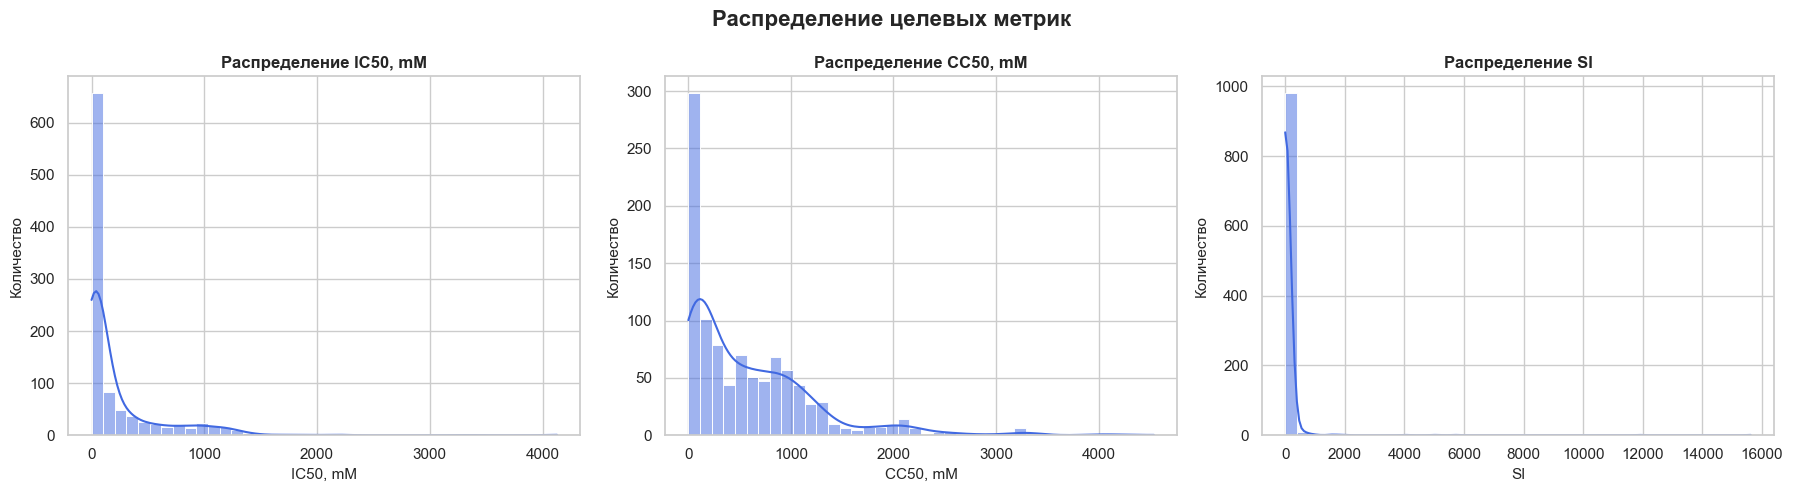

In [125]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение целевых метрик', fontsize=16, fontweight='bold')

targets = ['IC50, mM', 'CC50, mM', 'SI']

for i, col in enumerate(targets):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='royalblue', bins=40)
    axes[i].set_title(f'Распределение {col}', fontsize=12, fontweight='semibold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Количество', fontsize=11)

plt.tight_layout()
plt.show()

При визуализации данным мы наблюдаем:  
- IC50 (эффективность): демонстрирует ярко выраженную положительную асимметрию, подавляющее большинство исследуемых соединений сосредоточено в диапазоне малых концентраций (до 200 мМ). Однако присутствуют единичные неактивные молекулы с экстремальными значениями IC50 вплоть до 4000 мМ, формирующие длинный правый хвост распределения.  
- CC50 (цитотоксичность): имеет более сглаженный вид, однако также смещено влево. Основной массив данных расположен в зоне до 1000 мМ, при этом график плавно затухает к отметке 4500 мМ. Это указывает на существенное различие в уровнях безопасности исследуемых веществ.  
- SI (индекс селективности): обладает сильной степенью асимметрии, из-за наличия единичных высокоселективных соединений (максимум достигает 15620.6) практически весь массив данных (более 95%) визуально сливается в один плотный столбец около нуля (в пределах SI < 100).
Характер распределений показывает, что данные в сыром виде непригодны для классических моделей машинного обучения, соответственно необходимо преобразование данных.

## Преобразование целевых метрик (логарифмирование)

In [126]:
df['log_IC50'] = np.log10(df['IC50, mM'])
df['log_CC50'] = np.log10(df['CC50, mM'])
df['log_SI'] = np.log10(df['SI'])

log_targets = ['log_IC50', 'log_CC50', 'log_SI']
print(df[log_targets].describe())

          log_IC50     log_CC50       log_SI
count  1001.000000  1001.000000  1001.000000
mean      1.663692     2.406744     0.743052
std       0.940752     0.715710     0.753580
min      -2.453865    -0.154401    -1.939708
25%       1.097445     1.999996     0.156347
50%       1.668248     2.613883     0.585027
75%       2.352136     2.951381     1.219235
max       3.615795     3.656958     4.193698


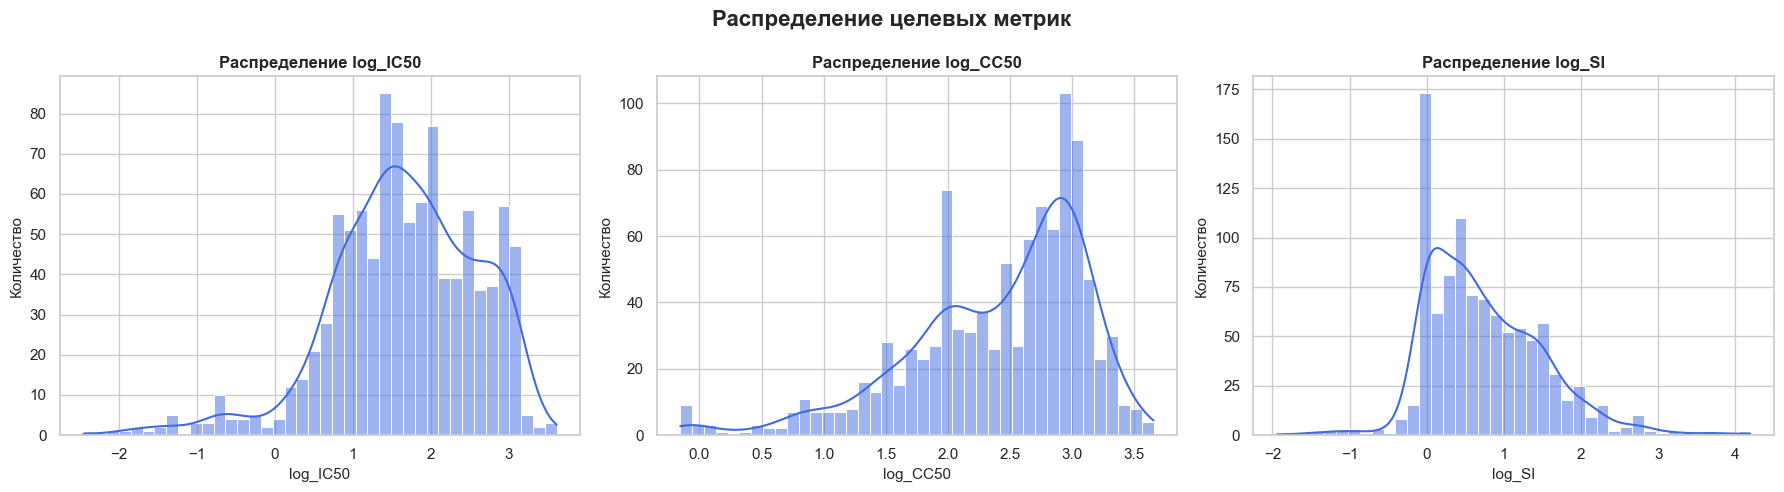

In [127]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Распределение целевых метрик', fontsize=16, fontweight='bold')

targets = ['log_IC50', 'log_CC50', 'log_SI']

for i, col in enumerate(targets):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='royalblue', bins=40)
    axes[i].set_title(f'Распределение {col}', fontsize=12, fontweight='semibold')
    axes[i].set_xlabel(col, fontsize=11)
    axes[i].set_ylabel('Количество', fontsize=11)

plt.tight_layout()
plt.show()

Анализ новых распределений позволяет сделать следующие выводы:  
- log_IC50 (эффективность): разброс данных сократился до диапазона от -2.45 до +3.61. Среднее (1.66) и медиана (1.67) полностью совпали, что означает симметричное распределение.  
- log_CC50 (безопасность): находится в рамках от -0.15 до +3.65, имеет стабильную дисперсию (std = 0.71) и сохраняет биологический сдвиг выборки в сторону безопасных, нетоксичных концентраций (медиана 2.61).  
- log_SI (индекс селективности): аномальный выброс 15620.6 сокращен до значения 4.19. 75%-й квантиль равен 1.21, а медиана 0.58. Это значит, что порог 1 находится как раз между 50% и 75% выборки.  
Логарифмическое преобразование позволило полностью устранить негативное влияние экстремальных выбросов и стабилизировать дисперсию целевых метрик.

In [128]:
targets = ['IC50, mM', 'CC50, mM', 'SI']
df = df.drop(columns=targets)

## Исследование признаков

Удалим технический столбец Unnamed - не несет в себе информации кроме нумерации строк.

In [129]:
df = df.drop(columns='Unnamed: 0')

### Проверка датасет на наличие константных признаков

In [130]:
nunique = df.nunique()
constant_features = nunique[nunique == 1]
constant_features

NumRadicalElectrons    1
SMR_VSA8               1
SlogP_VSA9             1
fr_N_O                 1
fr_SH                  1
fr_azide               1
fr_barbitur            1
fr_benzodiazepine      1
fr_diazo               1
fr_dihydropyridine     1
fr_isocyan             1
fr_isothiocyan         1
fr_lactam              1
fr_nitroso             1
fr_phos_acid           1
fr_phos_ester          1
fr_prisulfonamd        1
fr_thiocyan            1
dtype: int64

Список доказывает, что в датасете содержится 18 константных признаков, которые целесообразно удалить.

In [131]:
df = df.drop(columns=constant_features.index)

### Проверка датасет на наличие пропусков

In [132]:
print(df.isna().sum()[df.isna().sum() > 0])

MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
MinAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MWLOW           3
BCUT2D_CHGHI           3
BCUT2D_CHGLO           3
BCUT2D_LOGPHI          3
BCUT2D_LOGPLOW         3
BCUT2D_MRHI            3
BCUT2D_MRLOW           3
dtype: int64


Поскольку пропусков очень мало (всего 3 из 1001 строки, то есть менее 0.3%), их можно заполнить медианными значениями.

In [133]:
df = df.fillna(df.median(numeric_only=True))

In [134]:
print(df.isna().sum().sum())

0


### Проверка корреляции признаков

Поскольку в датасете довольно много колонок, классическая большая тепловая карта станет нечитаемой.  
Правильнее вывести топ самых сильно связанных между собой признаков в виде списка.

In [135]:
corr_matrix = df.corr().abs()
high_corr = corr_matrix.unstack().sort_values(ascending=False)
print(high_corr[(high_corr > 0.90) & (high_corr < 1.0)].head(100))

ExactMolWt           MolWt                  0.999999
MolWt                ExactMolWt             0.999999
Chi1                 HeavyAtomCount         0.998742
HeavyAtomCount       Chi1                   0.998742
MolWt                HeavyAtomMolWt         0.996850
                                              ...   
MinAbsPartialCharge  MaxPartialCharge       0.974730
NumValenceElectrons  Chi0v                  0.974373
Chi0v                NumValenceElectrons    0.974373
Chi3v                Chi3n                  0.972219
Chi3n                Chi3v                  0.972219
Length: 100, dtype: float64


Результат наглядно демонстрирует классическую мультиколлинеарность (избыточное дублирование информации).  
Чтобы избавить модель от дубликатов, удалим по одному признаку из каждой сильно связанной пары.

In [136]:
cols = ['log_IC50', 'log_CC50', 'log_SI']

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90) and column not in cols]
df = df.drop(columns=to_drop)

print(f"Удалено сильно связанных признаков: {len(to_drop)}")
print(f"Итоговое количество независимых признаков: {df.shape[1] - len(cols)}")


Удалено сильно связанных признаков: 47
Итоговое количество независимых признаков: 145


### Проверка наличия выбрасов в признаках

In [137]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
outliers = (df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))
outliers_count = outliers.sum().sort_values(ascending=False)

print(outliers_count.head(20))

VSA_EState10             250
VSA_EState9              245
fr_Al_OH                 243
fr_amide                 243
fr_aniline               222
Ipc                      218
fr_allylic_oxid          209
PEOE_VSA4                205
fr_ester                 199
PEOE_VSA13               185
PEOE_VSA5                166
fr_methoxy               154
fr_ketone                154
BCUT2D_MRHI              153
fr_para_hydroxylation    147
fr_aryl_methyl           144
SMR_VSA9                 141
fr_halogen               140
fr_Imine                 137
fr_alkyl_halide          136
dtype: int64


В рамках анализа признакового пространства была проведена оценка наличия выбросов с использованием метода межквартильного размаха. Наибольшее количество выбросов зафиксировано в дескрипторах фрагментного типа (например, fr_amide — 243, fr_Al_OH — 243, fr_aniline — 222), а также в топологических индексах (VSA_EState10 — 250, Ipc — 218).
С точки зрения химоинформатики, данные значения отражают структурные особенности редких или более сложных химических соединений, а не экспериментальные ошибки. Исключение данных объектов из выборки недопустимо, так как это приведет к потере уникальной структурной информации о перспективных молекулах.

### Масштабирование признаков

In [138]:
df.describe().T[['min', 'max', 'std']].sort_values(by='std', ascending=False).head(30)

,min,max,std
Ipc,107.107191,3.951781e+13,1.255969e+12
MolWt,110.156000,9.047770e+02,1.269464e+02
TPSA,0.000000,4.075000e+02,4.574383e+01
SMR_VSA7,0.000000,1.329597e+02,3.171897e+01
SMR_VSA5,0.000000,1.743680e+02,2.959406e+01
SlogP_VSA5,0.000000,1.840771e+02,2.663701e+01
SlogP_VSA2,0.000000,2.131382e+02,2.379270e+01
EState_VSA5,0.000000,2.703271e+02,2.247217e+01
PEOE_VSA7,0.000000,1.610621e+02,2.181757e+01
PEOE_VSA6,0.000000,1.288952e+02,2.062852e+01


Признаки имеют разные масштабы значений.  
Так как в пространстве химических дескрипторов было обнаружено высокое содержание выбросов (связанных со спецификой функциональных групп молекул), классический метод стандартизации StandardScaler не подходит. 
Будет использован алгоритм RobustScaler т.к. данный метод выполняет центрирование признаков по медиане и масштабирование по межквартильному размаху (IQR), что предотвращает искажение масштаба независимых переменных под влиянием экстремальных значений отдельных структур.

### Сохраняем итоговый датасет

In [139]:
df.to_csv('data_classic_ML.csv', index = False)
print(f'Итоговая размерность: {df.shape}')

Итоговая размерность: (1001, 148)
